# Loader

### Load modules

In [52]:
import numpy as np
from hmmlearn.hmm import CategoricalHMM
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import os
import vis_detect_helpers_v8 as hp
from matplotlib.backends.backend_pdf import PdfPages

### Load data

In [53]:
# Get the path to the Pickles folder
path = os.path.join(os.getcwd(), 'Pickles')

# Initialize an empty dataframe
all_data = pd.DataFrame()       # df for all sessions - for HMM fitting
expert_data = pd.DataFrame()    # df for expert sessions - for HMM decoding

# Iterate over the files in the Pickles folder
for file in os.listdir(path):
    if file.endswith('.pkl'):
        # Load the pickle file as a dataframe
        file_path = os.path.join(path, file)
        session_data = pd.read_pickle(file_path)
    
    session_data = session_data[session_data['protocol'] == 4]
    
    # Create a dictionary to map session dates to session numbers
    unique_sessions = session_data['session_date'].unique()
    session_number_map = {session_date: i + 1 for i, session_date in enumerate(unique_sessions)}

    # Create a new column with session numbers from 1 to the number of unique session dates
    session_data['session_number'] = session_data['session_date'].map(session_number_map)

    all_data = pd.concat([all_data, session_data])  # Concatenate the dataframes

    expert_sessions = hp.expert_state(session_data, num_sessions=5)
    expert_data = pd.concat([expert_data, expert_sessions])     # Concatenate the dataframes


/Users/beres/SWC/Github/vis_detect_analysis_Apr2023/vis_detect_helpers_v8.py:536: RuntimeWarning: invalid value encountered in scalar divide
  hit_rates_by_change_size = change_outcomes.groupby(['session_date', 'change_sizes_TF'])['outcomes'].apply(lambda x: (x == 'Hit').sum() / (x.isin(['Hit', 'Miss'])).sum())


# Constants

In [54]:
sns.set_context('talk')  # other options for context include paper (smaller), talk (bigger), and poster (biggest). Can also add 'scale' argument for axis text size

OUTCOME_PALETTE = {'Hit': 'green', 'FA': 'red', 'Miss': 'purple'}
OUTCOME_ORDER = ['FA', 'Hit', 'Miss']

HIDDEN_STATE_PALETTE = {'Hyper-engaged': "red", 'Disengaged': "purple", 'Engaged': "green"}

STATE_MAPPING = {0: 'HE', 1: 'DE', 2: 'E'}

# Set seed for reproducibility
SEED = 50

MODELS_NUM = 100 # Number of HMMs trained (best one picked)

# Formatting

### Filter mice, sessions, and trials

In [55]:
def filter_data(df):
    # Correct mouse IDs
    df.loc[df['mouse_id'] == '012 ', 'mouse_id'] = '012'
    df.loc[df['mouse_id'] == '18', 'mouse_id'] = '018'
    df.loc[df['mouse_id'] == '0120', 'mouse_id'] = '012'

    # Select mice to include in analysis
    df = df[df['mouse_id'].isin(['013', '016', '018', '019', '020', '021', '027', '028'])]

    # Filter by protocol, outcomes, and trial type
    df = df[df['outcomes'].isin(['Hit', 'FA', 'Miss'])]
    df = df[df['change_sizes_TF'] != 1]
    df = df.sort_values(by=['mouse_id', 'session_number'], axis=0, ignore_index=True)
    return df

all_data = filter_data(all_data)
expert_data = filter_data(expert_data)

## HMM on expert sessions

### Transform outcomes into the right format for CategoricalHMM

In [56]:
def transform_outcomes(data):
    # Group outcomes by (mouse_id, session_date)
    outcomes_list = data.groupby(['mouse_id', 'session_date'])['outcomes'].apply(list)

    # Flatten all outcomes and encode them into integers
    encoder = LabelEncoder()
    outcomes_flat = [outcome for session in outcomes_list for outcome in session]
    encoded_outcomes = encoder.fit_transform(outcomes_flat)

    # Convert each session's outcomes into integer-encoded NumPy arrays
    session_arrays = []
    start_idx = 0

    for outcomes in outcomes_list:
        session_length = len(outcomes)
        session_arrays.append(np.array(encoded_outcomes[start_idx : start_idx + session_length]))
        start_idx += session_length  # Move index forward

    # Concatenate all sessions for training
    concatenated_array = np.concatenate(session_arrays).reshape(-1, 1)

    # Create a list of lengths corresponding to each session
    session_lengths = [len(session) for session in session_arrays]

    return outcomes_list, session_arrays, concatenated_array, session_lengths, encoder

# Process expert data
expert_outcomes_list, expert_session_arrays, train_array, expert_session_lengths, expert_encoder = transform_outcomes(expert_data)

# Process all data
all_outcomes_list, all_session_arrays, all_array, all_session_lengths, all_encoder = transform_outcomes(all_data)

### Train HMM on expert sessions (change trials only, outcomes Miss/FA/Hit)

In [57]:
# Hyperparameter search: Train multiple models and keep the best one
best_model = None
best_score = -np.inf  

for _ in range(MODELS_NUM):  # Train multiple times
    model = CategoricalHMM(n_components=3, n_features=len(expert_encoder.classes_), random_state=SEED, n_iter=100)
    model.fit(train_array, expert_session_lengths)
    log_prob = model.score(train_array, expert_session_lengths)  
    
    if log_prob > best_score:  
        best_score = log_prob
        best_model = model

print("Best Model Score:", best_score)

# Print estimated parameters
print("Estimated Start Probabilities:\n", best_model.startprob_)
print("Estimated Transition Matrix:\n", best_model.transmat_)
print("Estimated Emission Probabilities:\n", best_model.emissionprob_)

Best Model Score: -13963.11978026671
Estimated Start Probabilities:
 [0.27416254 0.55085258 0.17498488]
Estimated Transition Matrix:
 [[9.95817886e-01 1.11029962e-15 4.18211422e-03]
 [1.90348890e-03 9.81246641e-01 1.68498699e-02]
 [4.18245757e-03 9.74442124e-03 9.86073121e-01]]
Estimated Emission Probabilities:
 [[0.83352468 0.16180783 0.00466749]
 [0.09791092 0.32491522 0.57717386]
 [0.46623025 0.47058669 0.06318306]]


### Decode expert sessions and save results in a single PDF

In [64]:
# Save figures into a multi-page PDF
pdf_filename = f'expert_hidden_3states_plots_seed{SEED}.pdf'
with PdfPages(pdf_filename) as pdf:
    # Decode each session separately using the best model
    for (mouse_id, session_date), session_outcomes in zip(expert_outcomes_list.index, expert_session_arrays):
        _, hidden_states = best_model.decode(session_outcomes.reshape(-1, 1), algorithm="viterbi")
        
        # Create DataFrame for plotting
        df = pd.DataFrame({
            "Trial": np.arange(1, len(session_outcomes)+1),
            "Observation": expert_encoder.inverse_transform(session_outcomes.ravel()),  # Convert back to categorical labels
            "Hidden State": hidden_states
        })

        df['Hidden State'] = df['Hidden State'].replace({0: 'Hyper-engaged', 1: 'Disengaged', 2: 'Engaged'})

        # Ensure correct outcome order
        df["Observation"] = pd.Categorical(df["Observation"], categories=OUTCOME_ORDER, ordered=True)

        # Create figure
        fig, ax = plt.subplots(figsize=(12.5, 6.5))
        sns.swarmplot(
            x="Trial", 
            y="Observation", 
            data=df, 
            hue="Hidden State", 
            palette=HIDDEN_STATE_PALETTE, 
            size=5, 
            ax=ax
        )
        sns.despine()

        # Customize plot
        plt.title(f"Observed Outcomes vs. Inferred Hidden States\nMouse {mouse_id}, Session {session_date}")
        plt.xlabel("Trial")
        plt.ylabel("Observed Outcome")
        plt.legend(title='Hidden State', loc='upper right', bbox_to_anchor=(1.1, 0.8), frameon=True, fontsize='x-small')

        # Save current figure to the PDF
        pdf.savefig(fig)
        plt.close(fig)  # Close the figure to free memory

print(f"Plots saved to {pdf_filename}")

Plots saved to expert_hidden_3states_plots_seed50.pdf


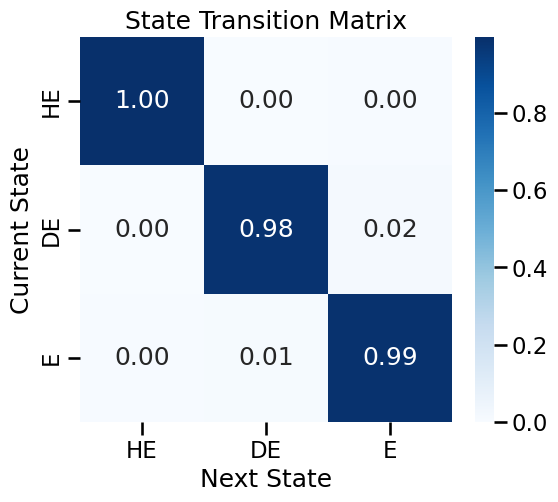

In [59]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.xticks(ticks=np.arange(3)+0.5, labels=[STATE_MAPPING[i] for i in range(3)])
plt.yticks(ticks=np.arange(3)+0.5, labels=[STATE_MAPPING[i] for i in range(3)])
plt.title("State Transition Matrix")
plt.show()

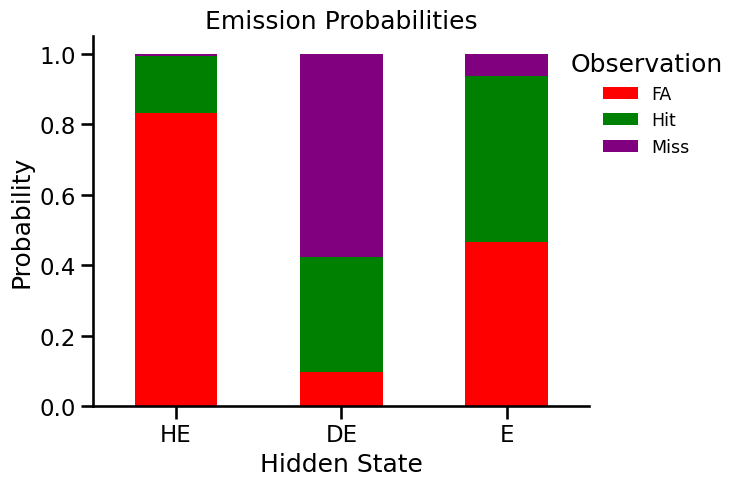

In [60]:
def plot_emission_probabilities(model, encoder):
    df = pd.DataFrame(model.emissionprob_, columns=encoder.classes_)
    df.index.name = "Hidden State"
    df = df[['FA', 'Hit', 'Miss']]      # Reorder the columns to be FA, Hit, Miss
    colors = ['red', 'green', 'purple']

    df.plot(kind="bar", stacked=True, color=colors)
    plt.title("Emission Probabilities")
    plt.ylabel("Probability")
    plt.xlabel("Hidden State")
    plt.xticks(ticks=np.arange(3), labels=[STATE_MAPPING[i] for i in range(3)], rotation=0)
    plt.legend(title='Observation', loc='upper right', bbox_to_anchor=(1.3, 1), frameon=False, fontsize='x-small')
    sns.despine()
    plt.show()

    

plot_emission_probabilities(best_model, expert_encoder)

### Decode all sessions and save results in a single PDF

In [61]:
# Save figures into a multi-page PDF
pdf_filename = f'allsessions_hidden_3states_plots_seed{SEED}.pdf'
with PdfPages(pdf_filename) as pdf:
    # Decode each session separately using the best model
    for (mouse_id, session_date), session_outcomes in zip(all_outcomes_list.index, all_session_arrays):
        _, hidden_states = best_model.decode(session_outcomes.reshape(-1, 1), algorithm="viterbi")

        # Create DataFrame for plotting
        df = pd.DataFrame({
            "Trial": np.arange(1, len(session_outcomes)+1),
            "Observation": all_encoder.inverse_transform(session_outcomes.ravel()),  # Convert back to categorical labels
            "Hidden State": hidden_states
        })

        df['Hidden State'] = df['Hidden State'].replace({0: 'Hyper-engaged', 1: 'Disengaged', 2: 'Engaged'})

        # Ensure correct outcome order
        df["Observation"] = pd.Categorical(df["Observation"], categories=OUTCOME_ORDER, ordered=True)

        # Create figure
        fig, ax = plt.subplots(figsize=(12.5, 6.5))
        sns.swarmplot(
            x="Trial", 
            y="Observation", 
            data=df, 
            hue="Hidden State", 
            palette=HIDDEN_STATE_PALETTE, 
            size=5, 
            ax=ax
        )
        sns.despine()

        # Customize plot
        plt.title(f"Observed Outcomes vs. Inferred Hidden States\nMouse {mouse_id}, Session {session_date}")
        plt.xlabel("Trial")
        plt.ylabel("Observed Outcome")
        plt.legend(title='Hidden State', loc='upper right', bbox_to_anchor=(1.1, 0.8), frameon=True, fontsize='x-small')

        # Save current figure to the PDF
        pdf.savefig(fig)
        plt.close(fig)  # Close the figure to free memory

print(f"Plots saved to {pdf_filename}")

Plots saved to allsessions_hidden_3states_plots_seed50.pdf


In [77]:
hidden_states_array_all = np.array([])

# Iterate over each session
for (mouse_id, session_date), session_outcomes in zip(all_outcomes_list.index, all_session_arrays):
    _, hidden_states = best_model.decode(session_outcomes.reshape(-1, 1), algorithm="viterbi")
    hidden_states_array_all = np.append(hidden_states_array_all, hidden_states)

all_data['hidden_states'] = hidden_states_array_all
all_data['hidden_states'] = all_data['hidden_states'].replace({0: 'Hyper-engaged', 1: 'Disengaged', 2: 'Engaged'})


hidden_states_array_expert = np.array([])

# Iterate over each session
for (mouse_id, session_date), session_outcomes in zip(expert_outcomes_list.index, expert_session_arrays):
    _, hidden_states = best_model.decode(session_outcomes.reshape(-1, 1), algorithm="viterbi")
    hidden_states_array_expert = np.append(hidden_states_array_expert, hidden_states)

expert_data['hidden_states'] = hidden_states_array_expert
expert_data['hidden_states'] = expert_data['hidden_states'].replace({0: 'Hyper-engaged', 1: 'Disengaged', 2: 'Engaged'})

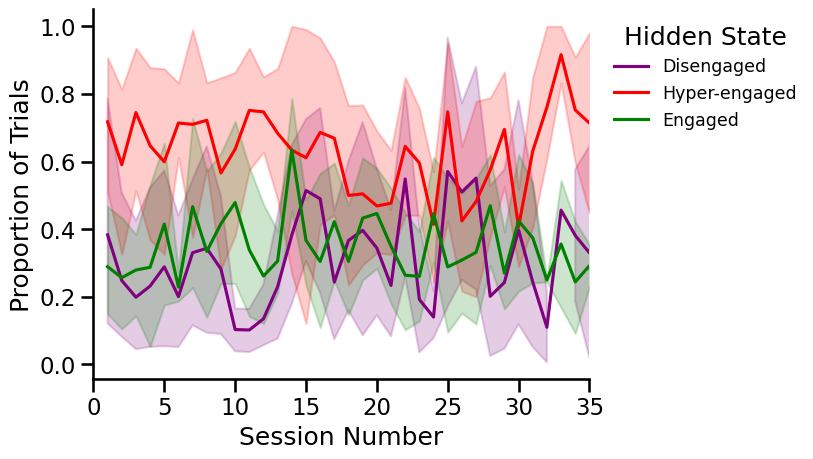

In [98]:
hidden_state_ratios = all_data.groupby(['mouse_id', 'session_number'])['hidden_states'].value_counts(normalize=True).fillna(0)

hidden_state_ratios.fillna(0)

hidden_state_ratios_df = pd.DataFrame(hidden_state_ratios).reset_index()

sns.lineplot(data=hidden_state_ratios_df, x='session_number', y='proportion', hue='hidden_states', palette=HIDDEN_STATE_PALETTE)
plt.xlabel('Session Number')
plt.ylabel('Proportion of Trials')
plt.xlim(0, 35)
plt.legend(title='Hidden State', loc='upper right', bbox_to_anchor=(1.45, 1), frameon=False, fontsize='x-small')
sns.despine()
plt.show()

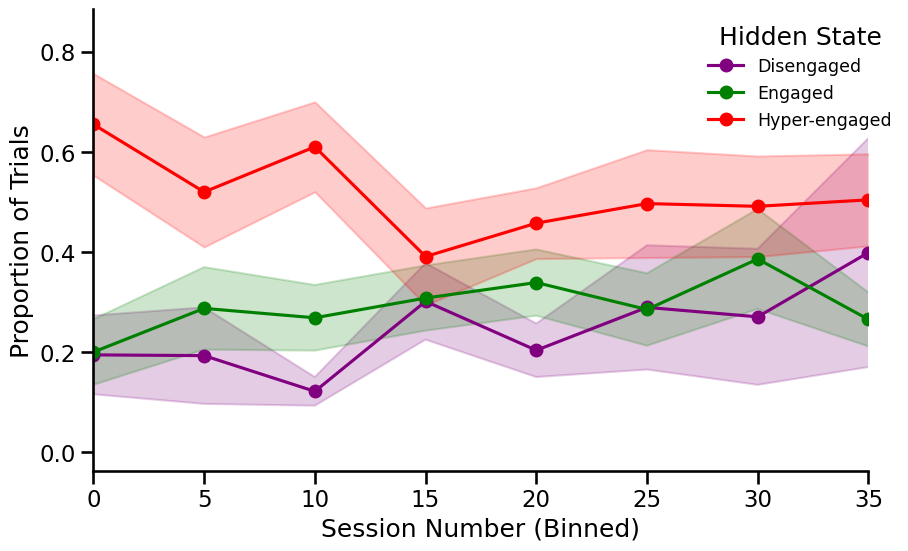

In [109]:
# Bin the session numbers into groups of 5
all_data['session_bin'] = (all_data['session_number'] // 5) * 5

# Calculate the mean and standard error for each bin
hidden_state_ratios_binned = all_data.groupby(['mouse_id', 'session_bin'])['hidden_states'].value_counts(normalize=True).fillna(0)
hidden_state_ratios_binned_df = pd.DataFrame(hidden_state_ratios_binned).reset_index()
hidden_state_ratios_binned_df.columns = ['mouse_id', 'session_bin', 'hidden_states', 'proportion']

# Calculate mean and standard error
binned_data = hidden_state_ratios_binned_df.groupby(['session_bin', 'hidden_states']).agg(
    mean_proportion=('proportion', 'mean'),
    std_proportion=('proportion', 'std'),
    count=('proportion', 'count')
).reset_index()

binned_data['sem_proportion'] = binned_data['std_proportion'] / np.sqrt(binned_data['count'])

# Plot the binned data with error bars
plt.figure(figsize=(10, 6))

# Plot each hidden state separately
for hidden_state in binned_data['hidden_states'].unique():
    state_data = binned_data[binned_data['hidden_states'] == hidden_state]
    plt.plot(state_data['session_bin'], state_data['mean_proportion'], label=hidden_state, color=HIDDEN_STATE_PALETTE[hidden_state], marker='o')
    plt.fill_between(state_data['session_bin'], 
                     state_data['mean_proportion'] - state_data['sem_proportion'], 
                     state_data['mean_proportion'] + state_data['sem_proportion'], 
                     alpha=0.2, color=HIDDEN_STATE_PALETTE[hidden_state])

plt.xlabel('Session Number (Binned)')
plt.ylabel('Proportion of Trials')
plt.xlim(0, 35)
plt.legend(title='Hidden State', loc='upper right', bbox_to_anchor=(1.05, 1), frameon=False, fontsize='x-small')
sns.despine()
plt.show()

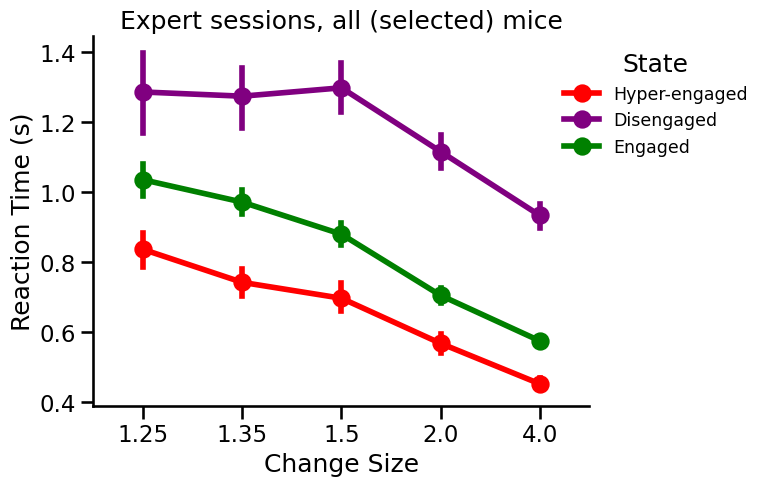

In [108]:
sns.pointplot(data=expert_data[expert_data['outcomes']=='Hit'], x='change_sizes_TF', y='reaction_times', hue='hidden_states', palette=HIDDEN_STATE_PALETTE, hue_order=['Hyper-engaged', 'Disengaged', 'Engaged'])
plt.xlabel('Change Size')
plt.ylabel('Reaction Time (s)')
plt.legend(title='State', loc='upper right', bbox_to_anchor=(1.35, 1), frameon=False, fontsize='x-small')
plt.title('Expert sessions, all (selected) mice')
sns.despine()
plt.show()


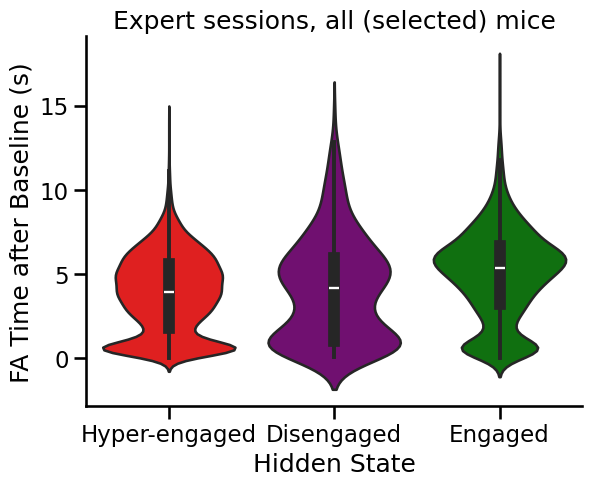

In [95]:
sns.violinplot(data=expert_data[expert_data['outcomes']=='FA'], x='hidden_states', y='reaction_times', 
               hue='hidden_states', order=['Hyper-engaged', 'Disengaged', 'Engaged'], palette=HIDDEN_STATE_PALETTE, legend=False)
plt.xlabel('Hidden State')
plt.ylabel('FA Time after Baseline (s)')
plt.title('Expert sessions, all (selected) mice')
sns.despine()
plt.show()
